## **Random Forest**

### **Import Libraries**

In [2]:
import numpy as np
import pandas as pd
import random

from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

### **Create  Dataset**

In [3]:
X, y = make_classification(
    n_samples=100,
    n_features=5,
    n_informative=5,
    n_redundant=0,
    n_clusters_per_class=1,
    random_state=42
)

df = pd.DataFrame(X, columns=['col1','col2','col3','col4','col5'])
df['target'] = y

print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,1.053909,-3.861208,1.530963,0.596692,1.030284,0
1,3.243492,1.666651,3.179016,-0.825861,0.778528,1
2,0.712446,-1.201617,1.528624,-0.422788,-0.376825,0
3,1.388329,1.538995,1.243716,0.740905,-2.081063,1
4,2.394647,-3.576345,0.914217,0.363136,2.110329,0


##  **Train-Test Split**

In [4]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## **Sampling Functions**

In [5]:
# Row Sampling (Bootstrap)
def sample_rows(df, percent):
    return df.sample(frac=percent, replace=True, random_state=None)


# Feature Sampling
def sample_features(df, percent):
    cols = random.sample(list(df.columns[:-1]), int(percent * (df.shape[1] - 1)))
    
    new_df = df.loc[:, cols].copy()
    new_df['target'] = df['target'].values
    
    return new_df


# Combined Sampling (Rows + Columns)
def combined_sampling(df, row_percent, col_percent):
    sampled_df = sample_rows(df, row_percent)
    return sample_features(sampled_df, col_percent)

## **Create Multiple Bootstrapped Datasets**

In [6]:
n_trees = 3   

datasets = []

for i in range(n_trees):
    sampled_df = combined_sampling(df, 0.5, 0.5)
    datasets.append(sampled_df)

# Check sampled datasets
for i, d in enumerate(datasets):
    print(f"Dataset {i+1} columns:", d.columns.tolist())

Dataset 1 columns: ['col5', 'col1', 'target']
Dataset 2 columns: ['col1', 'col3', 'target']
Dataset 3 columns: ['col1', 'col3', 'target']


## Train DT

In [7]:
models = []

for data in datasets:
    clf = DecisionTreeClassifier()
    
    X_sample = data.iloc[:, :-1]
    y_sample = data.iloc[:, -1]
    
    clf.fit(X_sample, y_sample)
    models.append((clf, X_sample.columns))  # store columns used

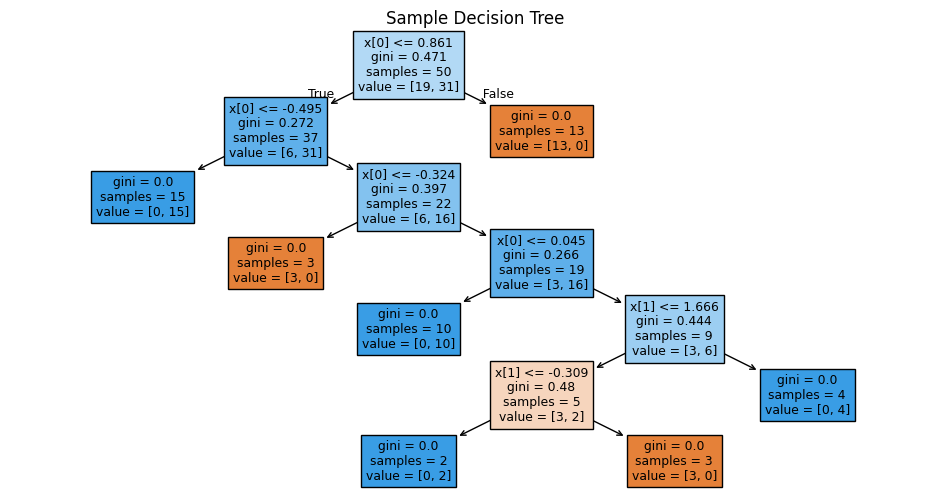

In [8]:
plt.figure(figsize=(12,6))
plot_tree(models[0][0], filled=True)
plt.title("Sample Decision Tree")
plt.show()

## **Prediction Function (Majority Voting)**

In [9]:
def predict_random_forest(models, X):
    predictions = []

    for clf, cols in models:
        preds = clf.predict(X[cols])
        predictions.append(preds)
    
    predictions = np.array(predictions)
    
    # Majority Voting
    final_pred = []
    for i in range(predictions.shape[1]):
        values, counts = np.unique(predictions[:, i], return_counts=True)
        final_pred.append(values[np.argmax(counts)])
    
    return np.array(final_pred)

In [10]:
y_pred_custom = predict_random_forest(models, X_test)

print("Custom Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_custom))

Custom Random Forest Accuracy: 0.95


In [11]:
# Train Model

In [12]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    bootstrap=True,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [13]:
y_pred = rf.predict(X_test)

print("Sklearn Random Forest Accuracy:",
      accuracy_score(y_test, y_pred))

Sklearn Random Forest Accuracy: 1.0


In [14]:
importance = rf.feature_importances_

for i, col in enumerate(X.columns):
    print(f"{col}: {importance[i]:.4f}")

col1: 0.0707
col2: 0.3642
col3: 0.1138
col4: 0.0453
col5: 0.4061


In [15]:
# Example: new input (must match number of features)
new_data = pd.DataFrame([{
    'col1': 0.5,
    'col2': -1.2,
    'col3': 0.3,
    'col4': -0.8,
    'col5': 1.1
}])

# Prediction
prediction = rf.predict(new_data)

print("Predicted Class:", prediction[0])

Predicted Class: 0
